# Figure 5
Plot daily mean maps of simulated anomalies due to pollution for cloud drop effective radius, cloud liquid water path, and surface cloud radiative effect.

In [113]:
from glob import glob
import xarray as xr
import datetime as dt
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors, colormaps
import matplotlib.lines as mlines
import cartopy.crs as ccrs
from pyproj import Transformer
import datetime as dt
import pandas as pd
import numpy as np
import string
import utils

## Read model output

In [10]:
simulations = {
    "ACI_OPT_2": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    }
}

In [76]:
seaice = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/SEAICE.nc").set_index(Time="XTIME")
landmask = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/LANDMASK.nc").set_index(Time="XTIME")
land = (landmask).where(~(seaice>0))
ocean = (land!=1)
seaice = seaice.where(ocean).groupby(seaice.Time.dt.day).mean().sel(day=[15,16,17])

outputpath = "/mnt/data/model_output/thompson_derived_variables"
variables = ["reff", "lwp", "sfc_cre"]
fnames = [glob(f"{outputpath}/{v}_2020-04-13_2020-04-17.nc")[0] for v in variables]
wrfout = xr.open_mfdataset(fnames)
wrfout

/tmp/ipykernel_4426/644672708.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(fnames)
/tmp/ipykernel_4426/644672708.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(fnames)
/tmp/ipykernel_4426/644672708.py:10: FutureWarning: In a future version of xarray the default value 

<xarray.Dataset> Size: 489MB
Dimensions:                  (simulation: 2, Time: 120, bottom_top: 49,
                              south_north: 99, west_east: 99)
Coordinates:
  * simulation               (simulation) <U28 224B 'ACI_OPT_2' 'ACI_OPT_2_NO...
    microphysics             (simulation) <U8 64B dask.array<chunksize=(2,), meta=np.ndarray>
    pollution_state          (simulation) <U8 64B dask.array<chunksize=(2,), meta=np.ndarray>
  * Time                     (Time) datetime64[ns] 960B 2020-04-13 ... 2020-0...
    XLAT                     (Time, south_north, west_east) float32 5MB dask.array<chunksize=(120, 99, 99), meta=np.ndarray>
    XLONG                    (Time, south_north, west_east) float32 5MB dask.array<chunksize=(120, 99, 99), meta=np.ndarray>
    longitude                (south_north, west_east) float32 39kB dask.array<chunksize=(99, 99), meta=np.ndarray>
    latitude                 (south_north, west_east) float32 39kB dask.array<chunksize=(99, 99), meta=np.ndarray>
Dimensions without coordinates: bottom_top, south_north, west_east
Data variables:
    RE_CLOUD_ACI             (simulation, Time, bottom_top, south_north, west_east) float32 461MB dask.array<chunksize=(2, 120, 49, 99, 99), meta=np.ndarray>
    cloud liquid water path  (simulation, Time, south_north, west_east) float32 9MB dask.array<chunksize=(2, 120, 99, 99), meta=np.ndarray>
    cloud_radiative_effect   (simulation, Time, south_north, west_east) float32 9MB dask.array<chunksize=(2, 120, 99, 99), meta=np.ndarray>

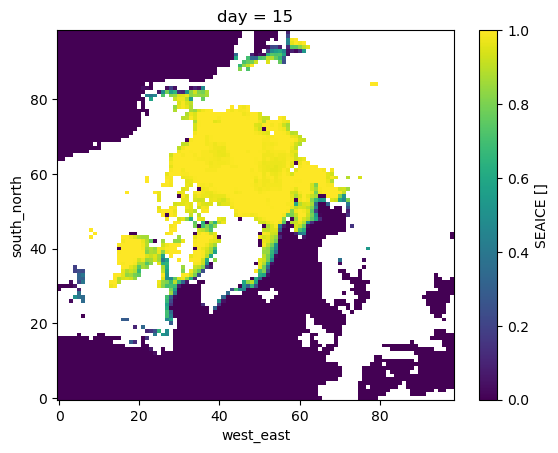

In [79]:
seaice.isel(day=0).plot()

### calculate shape of polluted air mass based on AOD anomalies

In [89]:
aod = []
for sim, meta in simulations.items():
    print(sim)
    ds = xr.open_dataset(f"/mnt/data/model_output/{sim}/AOD2D_OUT_2020-04-13_2020-04-17.nc").set_index(Time="XTIME")
    ds = ds.expand_dims({"simulation":[sim]})
    ds = ds.assign_coords({
        "day": ("Time",[T.dt.day for T in ds.Time]),
        "pollution_state": ("simulation",[meta["pollution_state"]]),
        "longitude": (["south_north","west_east"],ds.XLONG.isel(Time=0).values),
        "latitude": (["south_north","west_east"],ds.XLAT.isel(Time=0).values),
    })
    aod.append(ds)
aod = xr.concat(aod, dim="simulation")
aod_anom = aod.isel(simulation=aod.pollution_state=="polluted").squeeze() - aod.isel(simulation=aod.pollution_state=="clean").squeeze()


ACI_OPT_2
ACI_OPT_2_NO_ANTHRO_NO_FIRES


In [90]:
min_lat = 70
aod_90pc = np.percentile(abs(aod_anom.AOD2D_OUT.values.flatten()), 90)
aod_anom = aod_anom.where(aod_anom.latitude>min_lat)
airmass_flag = (abs(aod_anom.AOD2D_OUT)>aod_90pc)  # True in plume, False otherwise


In [91]:
wrfout_anom = wrfout.sel(simulation=wrfout.pollution_state=="polluted").squeeze() - wrfout.sel(simulation=wrfout.pollution_state=="clean").squeeze()
wrfout_anom = wrfout_anom.groupby(wrfout_anom.Time.dt.day).mean().sel(day=[15,16,17])
airmass_flag = airmass_flag.groupby(airmass_flag.Time.dt.day).any().sel(day=[15,16,17])

## Read MOSAiC position

In [127]:
mosaic = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic = mosaic.assign_coords({"day": ("time", [T.dt.day for T in mosaic.time])})
mosaic = mosaic.groupby(mosaic.day).mean()
mosaic = mosaic.sel(day=wrfout_anom.day.values)


## Plot

In [104]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2



In [72]:
transformer = Transformer.from_crs(
    "EPSG:4326",
    ccrs.NorthPolarStereo(central_longitude=-25).proj4_init,
    always_xy=True
)
x, y = transformer.transform(
    wrfout.longitude.values,
    wrfout.latitude.values
)

In [128]:
def plot_sea_ice_extent(ax, seaice, x, y, c="k"):
    ax.contour(
        x, y,
        seaice,
        levels=[0.5],
        colors=[c],
        linestyles=["dashed"],
    )
    return

def plot_airmass_outline(ax, airmass, x, y, c="k"):
    ax.contour(
        x, y,
        (airmass>0),
        levels=[0.5],
        colors=[c],
    )
    return

def plot_mosaic(ax, mosaic):
    ax.plot(
        mosaic.Longitude,
        mosaic.Latitude,
        "r*",
        transform=ccrs.PlateCarree(),
        ms=15,
        mec="w", mfc="r",
    )
    return

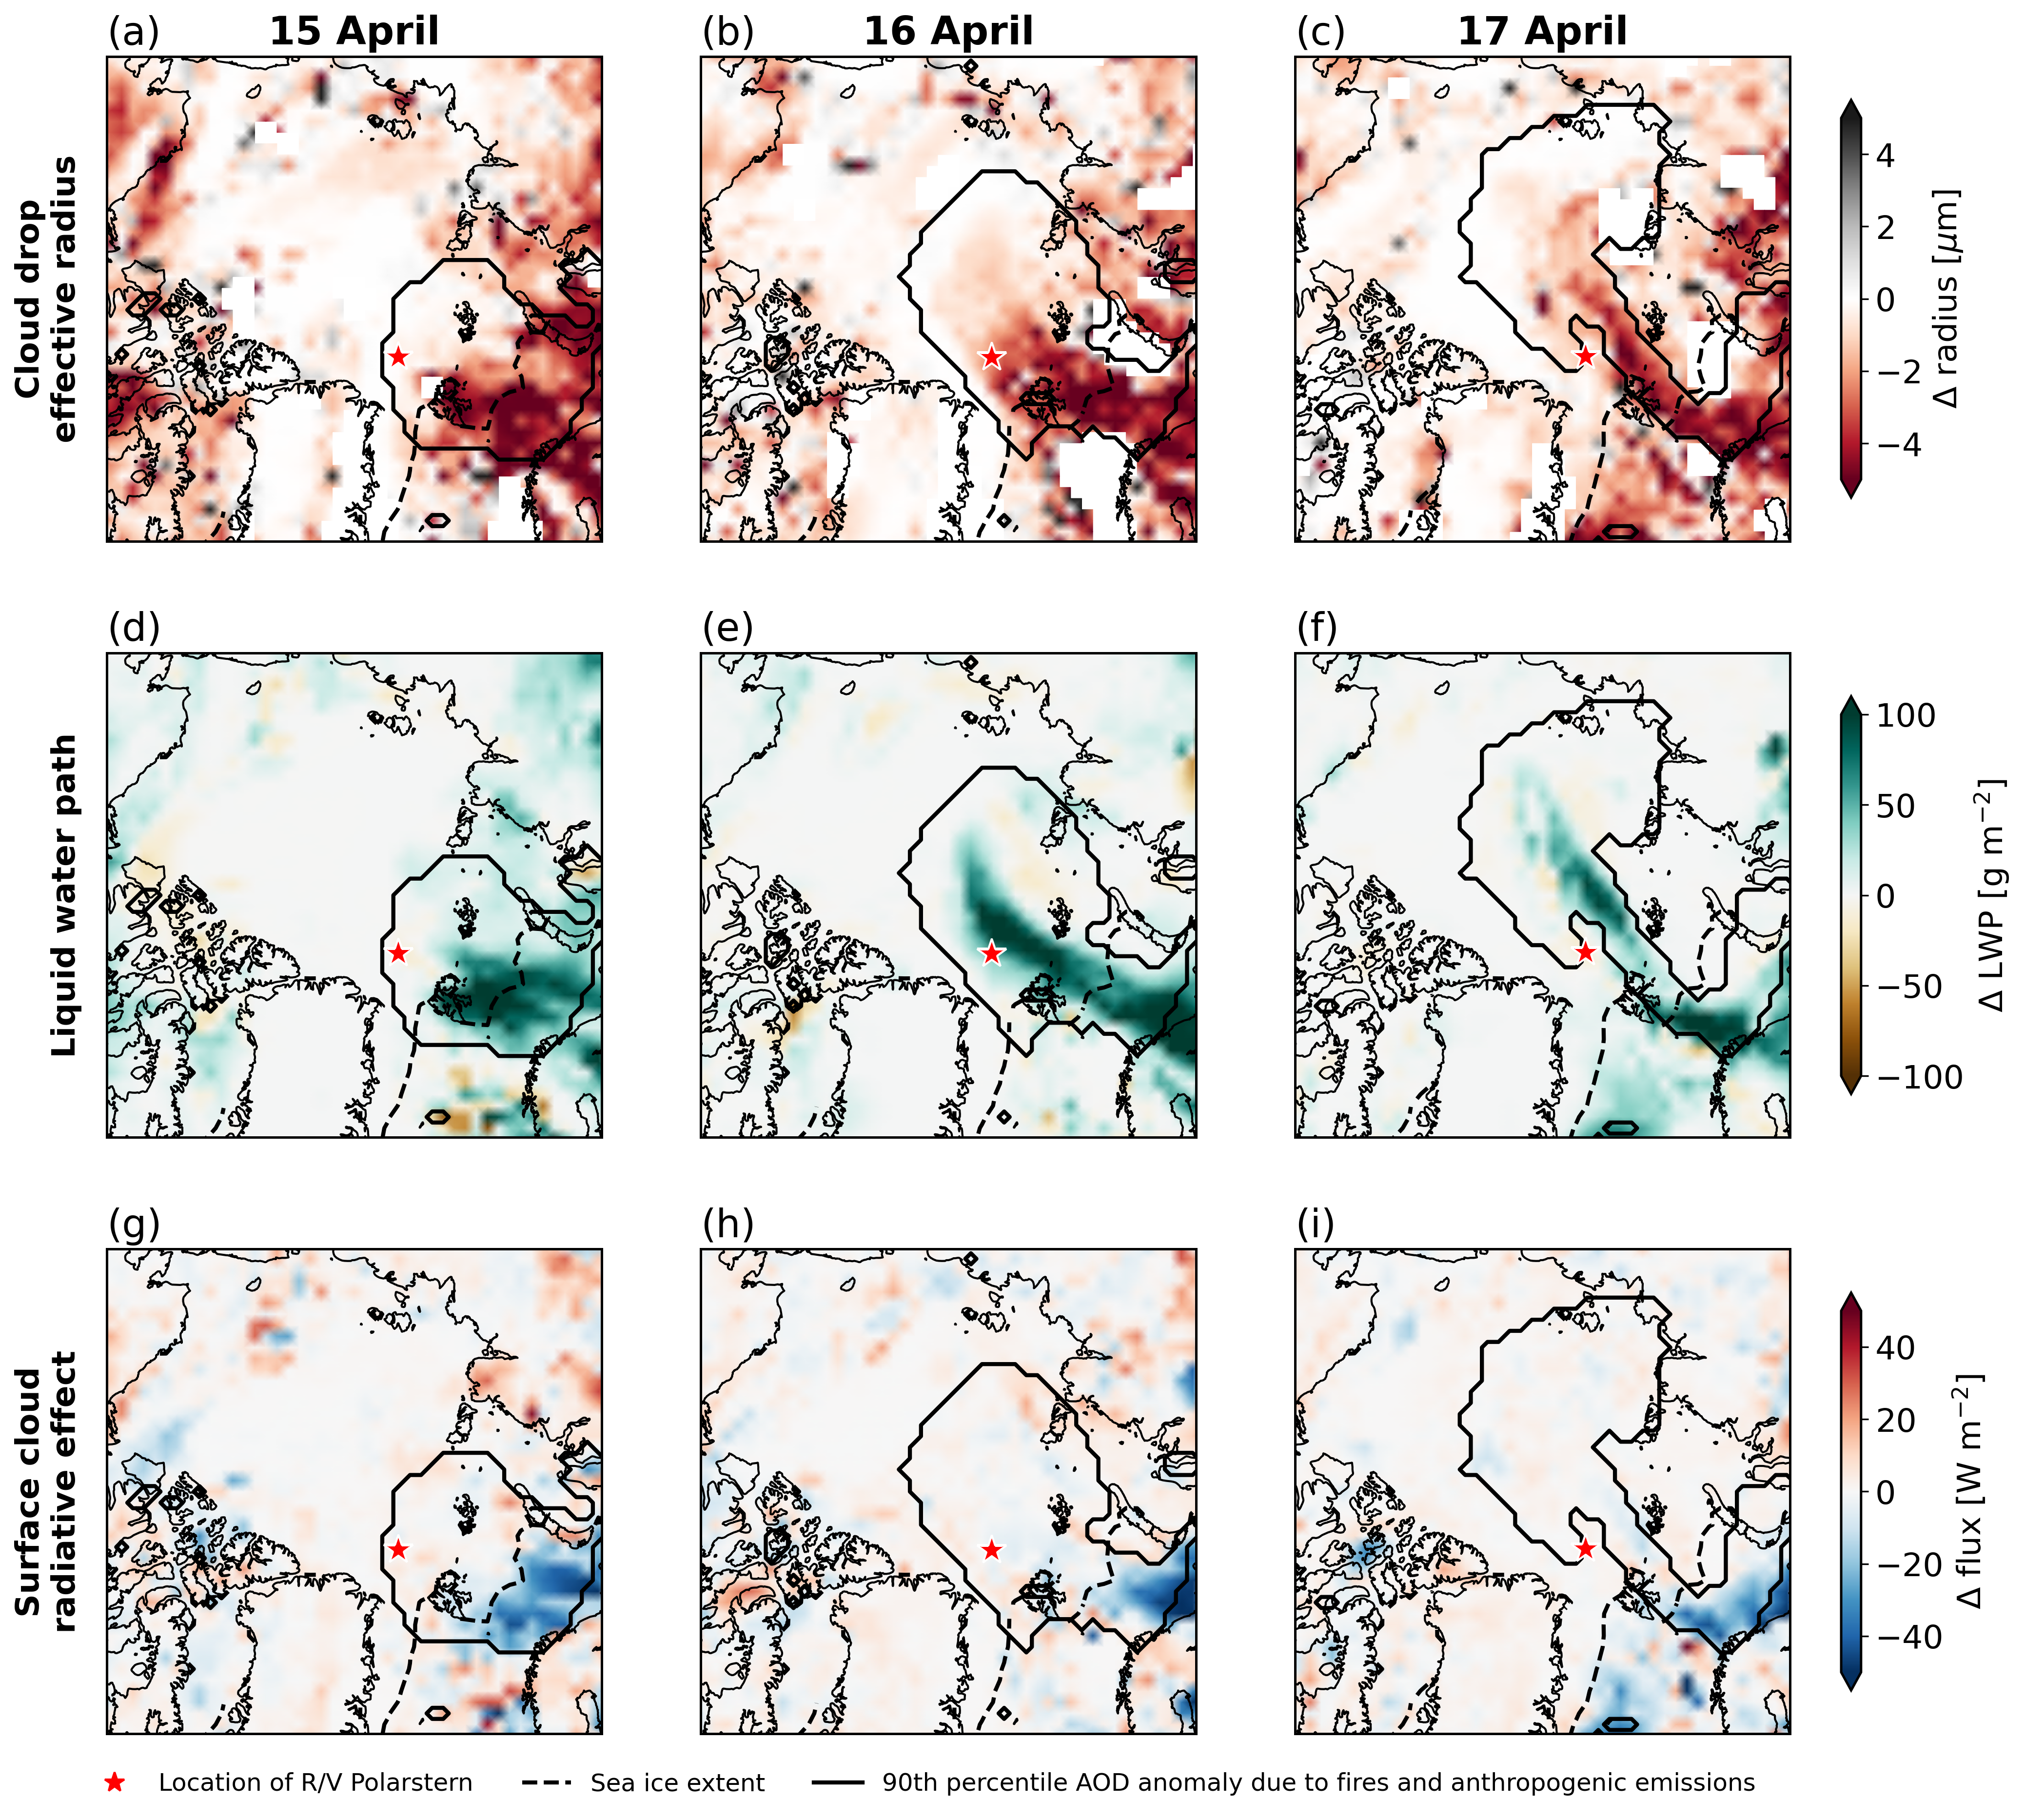

In [129]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(18,15),
    dpi=300,
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-25))
)
for n,ax in enumerate(axes.flatten()):
    ax.set_extent([-180,180,70,90], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(f"({string.ascii_lowercase[n]})", loc="left")

for d in range(len(wrfout_anom.day)):
    axes[0,d].set_title(
        f"{wrfout_anom.day.values[d]} April",
        weight="bold"
    )
    r_mesh = axes[0,d].pcolormesh(
        wrfout.longitude,
        wrfout.latitude,
        1e6*wrfout_anom.RE_CLOUD_ACI.isel(day=d, bottom_top=slice(0,10)).mean("bottom_top"),
        transform=ccrs.PlateCarree(),
        cmap="RdGy",
        vmin=-5, vmax=5,
        shading="gouraud"
    )

    l_mesh = axes[1,d].pcolormesh(
        wrfout.longitude,
        wrfout.latitude,
        1e3*wrfout_anom["cloud liquid water path"].isel(day=d),
        transform=ccrs.PlateCarree(),
        cmap="BrBG",
        vmin=-100, vmax=100,
        shading="gouraud"
    )

    c_mesh = axes[2,d].pcolormesh(
        wrfout.longitude,
        wrfout.latitude,
        wrfout_anom.cloud_radiative_effect.isel(day=d),
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-50, vmax=50,
        shading="gouraud"
    )
    for r in range(3):
        plot_sea_ice_extent(axes[r,d], seaice.isel(day=d), x, y)
        plot_airmass_outline(axes[r,d], airmass_flag.isel(day=d), x, y)
        plot_mosaic(axes[r,d], mosaic.isel(day=d))

plt.colorbar(r_mesh, label="$\\Delta$ radius [$\\mu$m]", ax=axes[0], extend="both", shrink=0.8, pad=0.025)
plt.colorbar(l_mesh, label="$\\Delta$ LWP [g m$^{{-2}}$]", ax=axes[1], extend="both", shrink=0.8, pad=0.025)
plt.colorbar(c_mesh, label="$\\Delta$ flux [W m$^{{-2}}$]", ax=axes[2], extend="both", shrink=0.8, pad=0.025)

axes[0,0].text(
    s="Cloud drop\neffective radius",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[0,0].transAxes,
    weight="bold",
    rotation=90,
)

axes[1,0].text(
    s="Liquid water path",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[1,0].transAxes,
    weight="bold",
    rotation=90,
)

axes[2,0].text(
    s="Surface cloud\nradiative effect",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[2,0].transAxes,
    weight="bold",
    rotation=90,
)

legend_handles = [mlines.Line2D([],[],ls="None",marker="*",ms=10,c="r",label="Location of R/V Polarstern")]
legend_handles.append(mlines.Line2D([],[],c="k",ls="dashed",label="Sea ice extent"))
legend_handles.append(mlines.Line2D([],[],c="k",label="90th percentile AOD anomaly due to fires and anthropogenic emissions"))
fig.legend(
    ncols=3,
    handles=legend_handles,
    loc="center",
    bbox_to_anchor=(-0.065, 0.04, 1, 0.1),
    edgecolor="None",
    borderaxespad=0.25,
    fontsize=12
)

plt.savefig("figures/figure5.png", bbox_inches="tight")